# justviz — Quick-start gallery

One cell per chart type. All return `(height, width, 4)` `uint8` RGBA arrays (or `None` when `interactive=True`).

| Notebook | Chart | What it does |
|----------|-------|--------------|
| `01_scatter` | `scatter()` | 2D point clouds, multi-layer, Parquet |
| `02_bar` | `bar()` | Vertical bar charts |
| `03_clusters` | `clusters()` | 2D embeddings coloured by label, per-cluster slides |
| `04_distances` | `distances()` | Pairwise distance heatmap |
| `05_graph` | `graph()` | Network graph (NetworkX or DataFrames) |
| `06_timeline` | `timeline()` | Multi-series temporal dot-chains |
| `07_explore` | `explore()` | Scatter + column-mapped color/size/facet |
| `08_story` | `story()` | Click-through storyboard presentation |

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from PIL import Image
from IPython.display import display
import justviz as jv

print(f"justviz {jv.__version__}")

justviz 0.1.0a2


## scatter

scatter: 200,000 points, 800×600, render 348.5ms


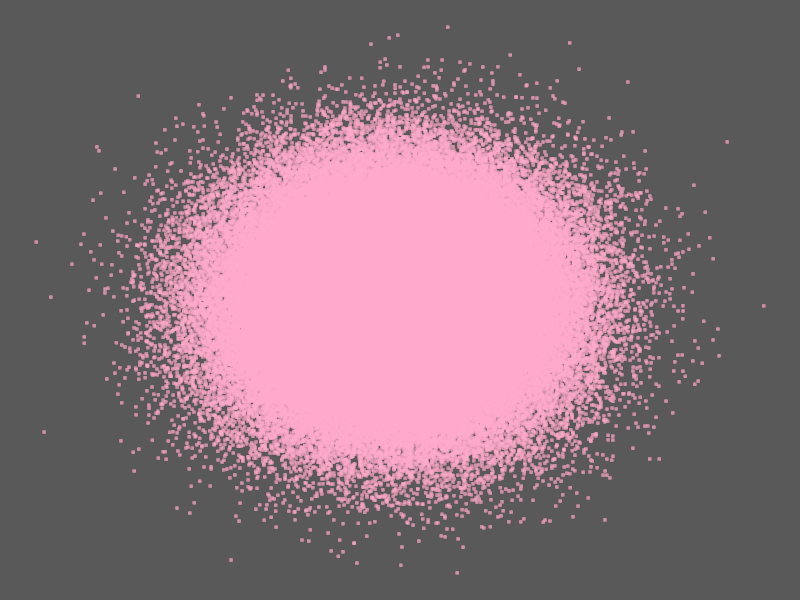

In [2]:
rng = np.random.default_rng(0)
x = rng.normal(50, 15, 200_000).astype(np.float32)
y = rng.normal(50, 15, 200_000).astype(np.float32)
img = jv.scatter(x, y, color=(1.0, 0.4, 0.6), size=2.0, opacity=0.6)
display(Image.fromarray(img, mode='RGBA'))

## bar

bar: 12 bars, 800×600, render 2.8ms


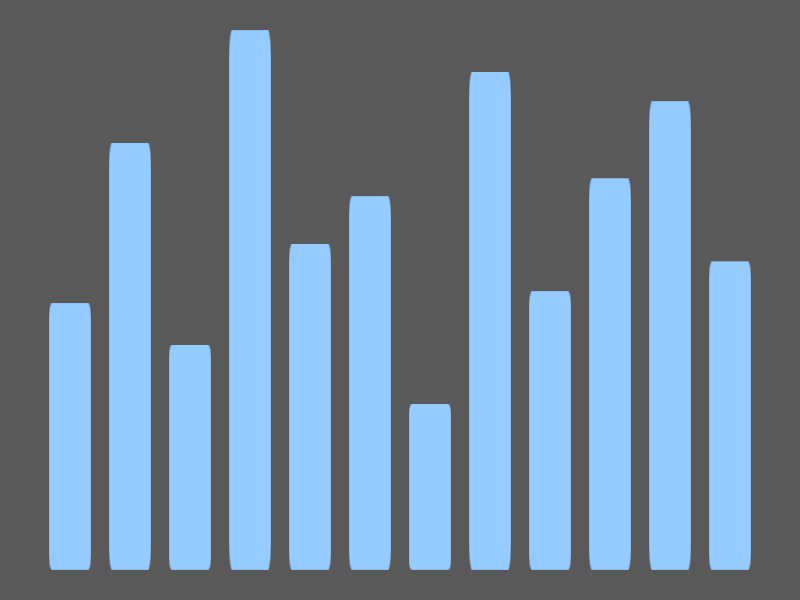

In [3]:
cats = np.arange(12, dtype=np.float32)
vals = np.array([45, 72, 38, 91, 55, 63, 28, 84, 47, 66, 79, 52], dtype=np.float32)
img = jv.bar(cats, vals, color=(0.3, 0.6, 1.0), bar_width=0.7)
display(Image.fromarray(img, mode='RGBA'))

## clusters

clusters: 45,000 points (3 layers), 1024×768, render 16.1ms


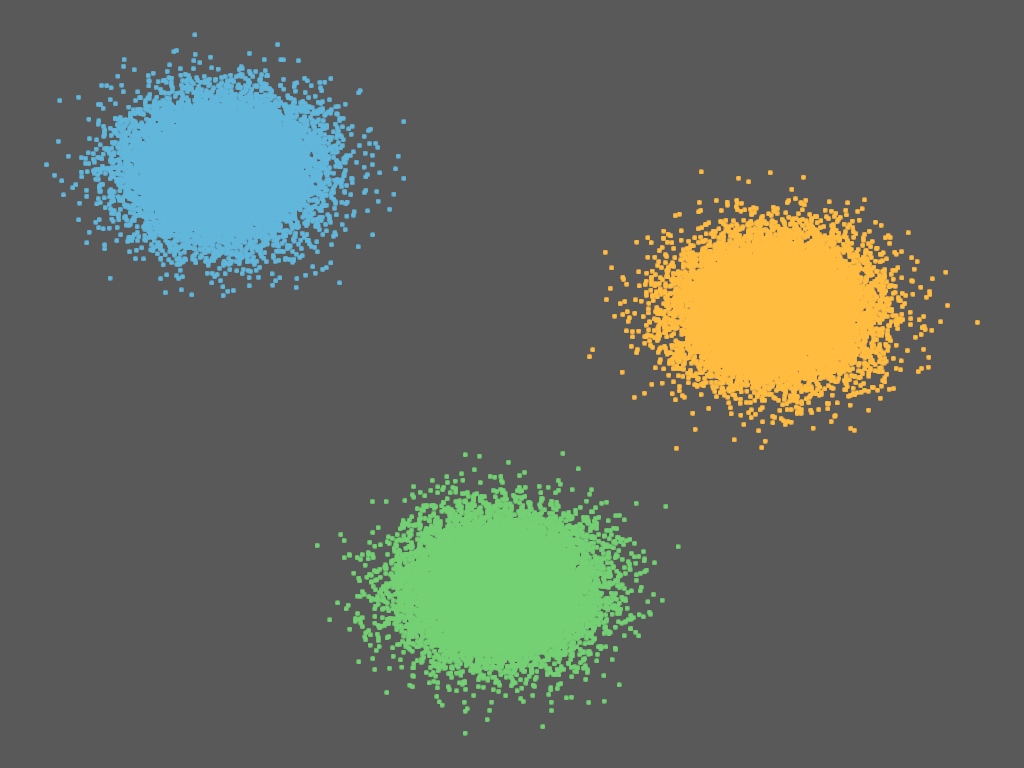

In [4]:
rng = np.random.default_rng(1)
data = np.vstack([
    rng.normal([20, 20], 5, (15_000, 2)),
    rng.normal([80, 40], 5, (15_000, 2)),
    rng.normal([50, 80], 5, (15_000, 2)),
]).astype(np.float32)
labels = np.repeat([0, 1, 2], 15_000).astype(np.int32)

img = jv.clusters(data, labels=labels, names=["Group A", "Group B", "Group C"],
                  size=2.5, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## distances

distances: 60×60 (3,600 cells), 600×600, render 3.6ms


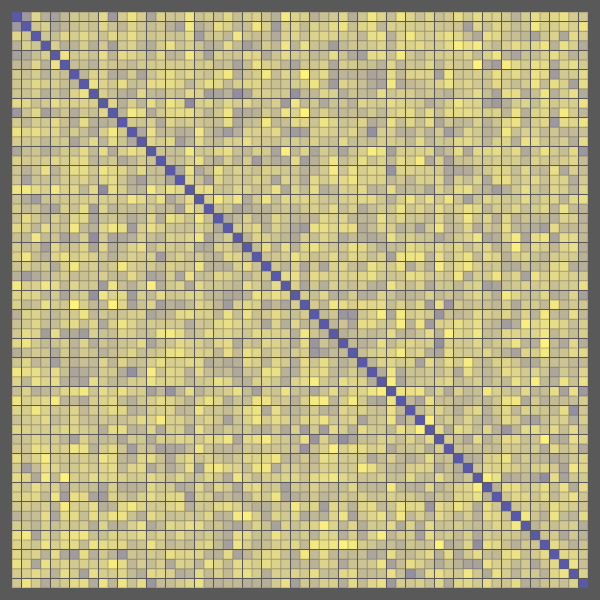

In [5]:
rng = np.random.default_rng(2)
emb = rng.standard_normal((60, 16)).astype(np.float32)
img = jv.distances(emb, metric="cosine", width=600, height=600)
display(Image.fromarray(img, mode='RGBA'))

## graph

graph: 34 nodes, 78 edges, 12,876 instances, render 6.6ms


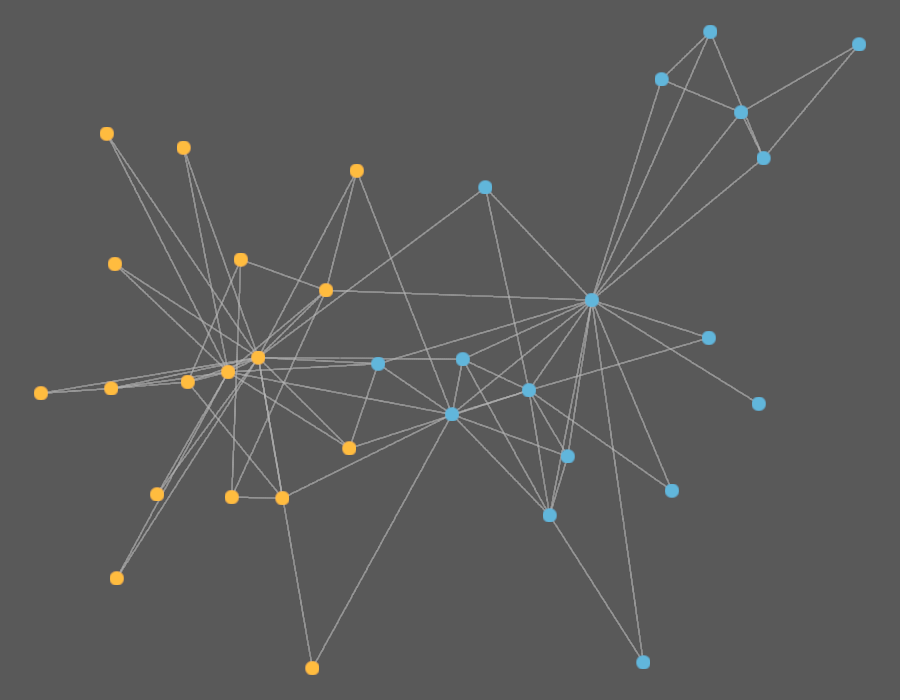

In [6]:
G = nx.karate_club_graph()
img = jv.graph(G, layout="spring", color_by="club",
               node_size=7.0, edge_opacity=0.35, width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))

## timeline

timeline: 2 series, 4,402 instances, 1000×500, render 4.0ms


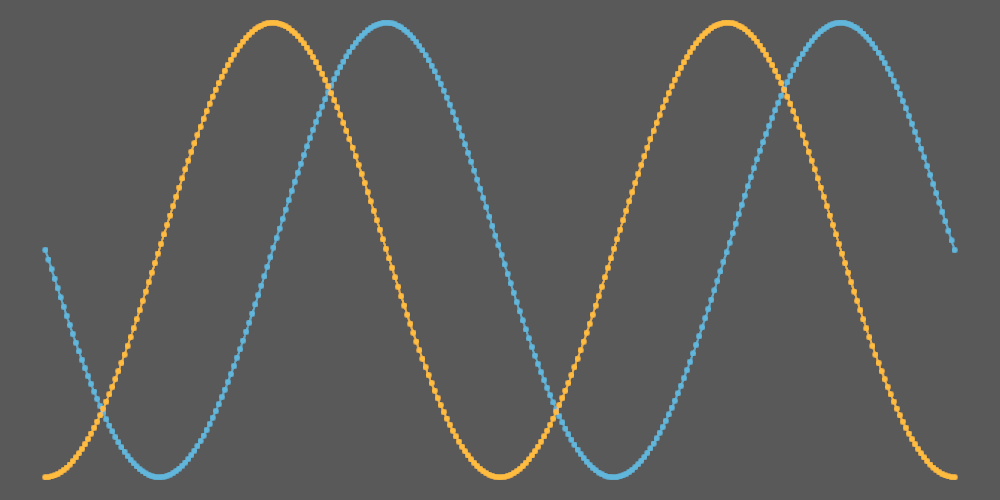

In [7]:
rng = np.random.default_rng(3)
t = np.linspace(0, 4 * np.pi, 300).astype(np.float32)

img = jv.timeline({
    "sin": (t, np.sin(t).astype(np.float32)),
    "cos": (t, np.cos(t).astype(np.float32)),
}, node_size=3.0, edge_size=1.2, edge_opacity=0.7, width=1000, height=500)
display(Image.fromarray(img, mode='RGBA'))

## explore

In [ ]:
rng = np.random.default_rng(4)
n = 10_000
df = pd.DataFrame({
    "x":      rng.normal(0, 1, n).astype(np.float32),
    "y":      rng.normal(0, 1, n).astype(np.float32),
    "class":  rng.choice(["A", "B", "C", "D"], n),
    "weight": rng.exponential(1, n).astype(np.float32),
})

img = jv.explore(df, x="x", y="y",
                 color="class", size="weight",
                 opacity=0.75, width=900, height=700)
display(Image.fromarray(img, mode='RGBA'))

## story (interactive — run separately)

`story()` opens a GPU window and blocks until closed. Uncomment to run.

In [ ]:
# rng = np.random.default_rng(5)
# x1 = rng.normal(30, 10, 50_000).astype(np.float32)
# y1 = rng.normal(30, 10, 50_000).astype(np.float32)
# x2 = rng.normal(70, 10, 50_000).astype(np.float32)
# y2 = rng.normal(70, 10, 50_000).astype(np.float32)
#
# jv.story(
#     layers=[
#         {"x": x1, "y": y1, "color": (0.95, 0.26, 0.21), "size": 2.0},
#         {"x": x2, "y": y2, "color": (0.13, 0.59, 0.95), "size": 2.0},
#     ],
#     slides=[
#         {"title": "Full dataset",     "zoom": "fit", "layers": "all"},
#         {"title": "Cluster A (red)",  "zoom": "fit", "layers": [1]},
#         {"title": "Cluster B (blue)", "zoom": "fit", "layers": [2]},
#     ],
# )